## BTC data merge

This section loads the available BTC datasets from `../Data`, standardizes them, and combines them into one time series table.

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

In [43]:
daily_btc = pd.read_csv(
    "../Data/btc_3years_daily.csv",
    parse_dates=["Date"],
).rename(columns={"BTC-USD": "price"})
daily_btc["frequency"] = "daily"
daily_btc = daily_btc.set_index("Date", drop=False).sort_index()

hourly_btc = pd.read_csv(
    "../Data/btc_6months_1h.csv",
    parse_dates=["Date"],
).rename(columns={"BTC-USD": "price"})
hourly_btc["frequency"] = "hourly"
hourly_btc = hourly_btc.set_index("Date", drop=False).sort_index()

btc_data = pd.concat([daily_btc, hourly_btc]).sort_index()
btc_data.head()

,Date,price,frequency
Date,,,
2023-04-03,2023-04-03,27800.00,daily
2023-04-04,2023-04-04,28165.47,daily
2023-04-05,2023-04-05,28170.01,daily
2023-04-06,2023-04-06,28033.82,daily
2023-04-07,2023-04-07,27906.33,daily


In [44]:
btc_data.groupby("frequency")["price"].agg(["count", "min", "max", "mean"])

,count,min,max,mean
frequency,,,,
daily,1096,25128.6,124658.54,69964.411332
hourly,4368,62900.0,126011.18,87999.616511


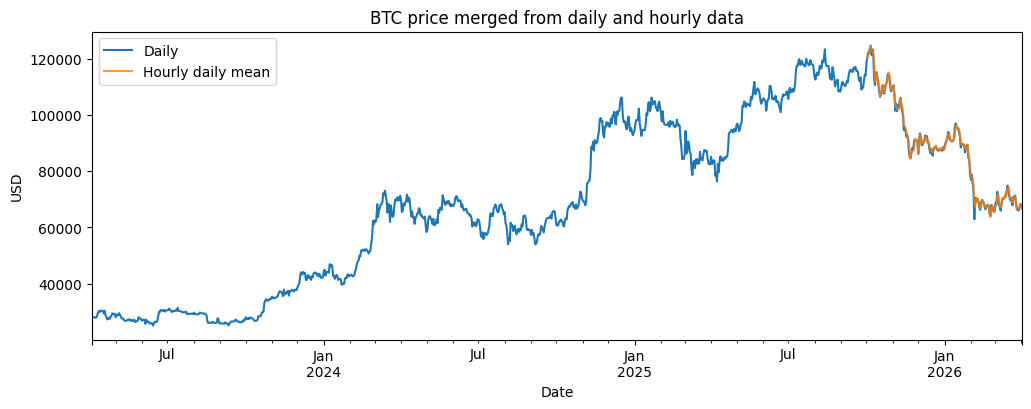

In [45]:
fig, ax = plt.subplots(figsize=(12, 4))
daily_btc["price"].plot(ax=ax, label="Daily")
hourly_btc["price"].resample("D").mean().plot(ax=ax, label="Hourly daily mean", alpha=0.8)
ax.set_title("BTC price merged from daily and hourly data")
ax.set_ylabel("USD")
ax.legend()
plt.show()

In [46]:
btc_data.isna().sum()

Date         0
price        0
frequency    0
dtype: int64

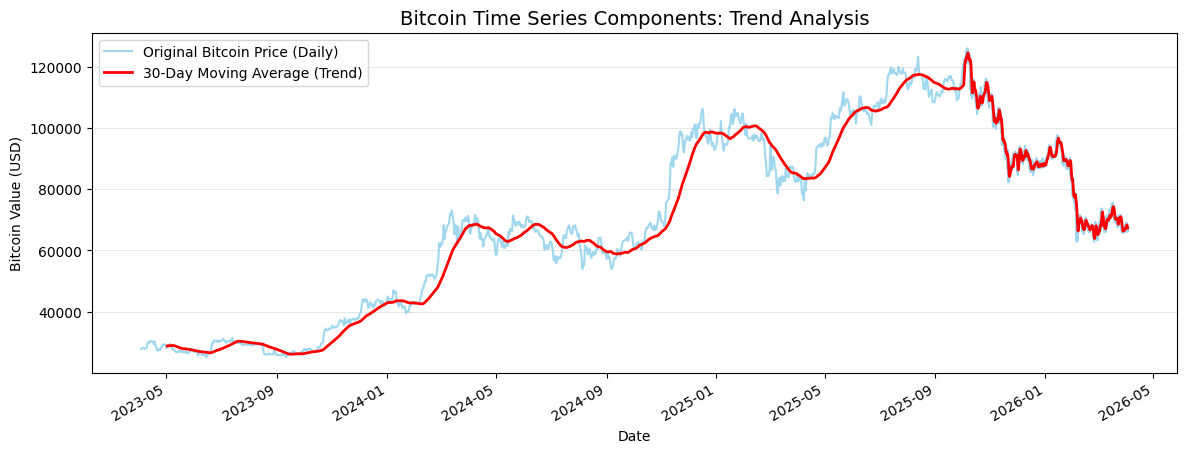

In [47]:
# Recipe 1-4A 
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Plot 1: Trực quan hóa giá trị chuỗi thời gian 
btc_data['price'].plot(color='skyblue', label='Original Bitcoin Price (Daily)', alpha=0.8)

# Plot 2: Vẽ thêm đường trung bình động (MA - Moving Average) 30 ngày để "làm mịn" 
# và nhìn rõ phần "Trend" đang đi lên hay đi xuống
btc_data['price'].rolling(window=30).mean().plot(color='red', linewidth=2, label='30-Day Moving Average (Trend)')

plt.title('Bitcoin Time Series Components: Trend Analysis', fontsize=14)
plt.ylabel('Bitcoin Value (USD)')
plt.xlabel('Date')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

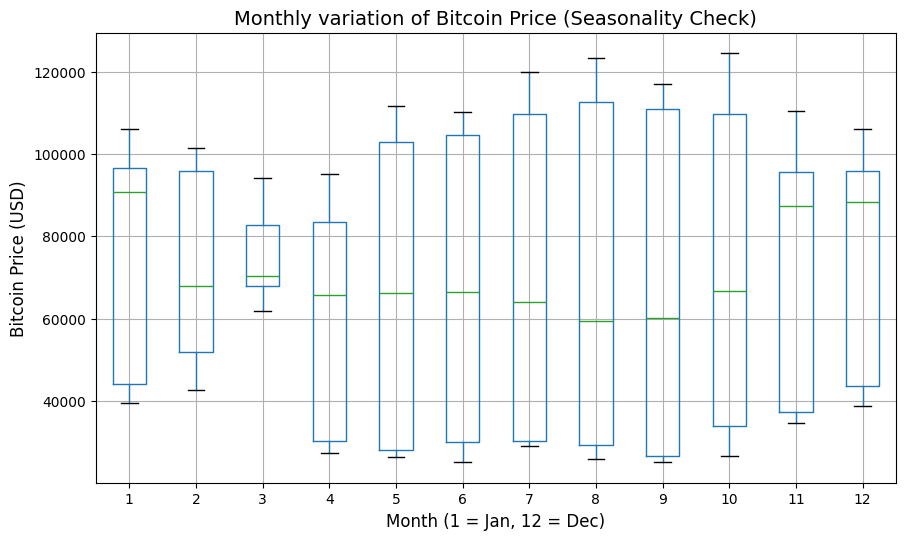

In [48]:
# Recipe 1-4B
import pandas as pd
import matplotlib.pyplot as plt

# 1. Trích xuất chỉ dữ liệu giá daily (bỏ qua hourly để dễ quan sát biến động qua các tháng)
daily_price = btc_data['price'].resample('D').mean().dropna()

# Dữ liệu sẽ chia các value thành 12 cột box tương ứng với 12 tháng trong năm
df_month = pd.DataFrame({
    'Month': daily_price.index.month,
    'Price (USD)': daily_price.values
})

# 3. Vẽ biểu đồ hộp (Boxplot) 
fig, ax = plt.subplots(figsize=(10, 6))
df_month.boxplot(by='Month', column=['Price (USD)'], ax=ax, grid=True, flierprops=dict(marker='o', markersize=4, alpha=0.3))

plt.title('Monthly variation of Bitcoin Price (Seasonality Check)', fontsize=14)
plt.suptitle('') # Xóa title mặc định của Pandas sinh ra phía trên
plt.xlabel('Month (1 = Jan, 12 = Dec)', fontsize=12)
plt.ylabel('Bitcoin Price (USD)', fontsize=12)
plt.show()

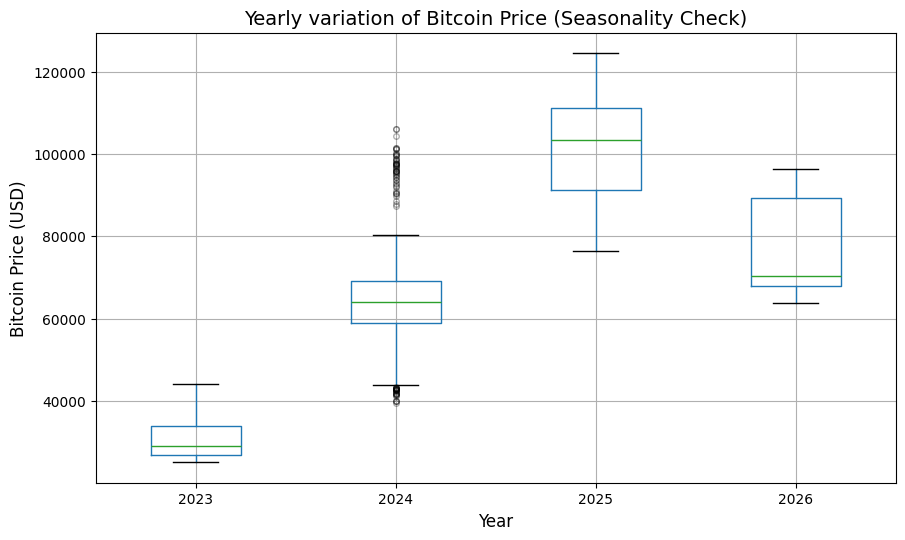

In [49]:
df_year = pd.DataFrame({
    'Year': daily_price.index.year,
    'Price (USD)': daily_price.values
})

# 3. Vẽ biểu đồ hộp (Boxplot) 
fig, ax = plt.subplots(figsize=(10, 6))
df_year.boxplot(by='Year', column=['Price (USD)'], ax=ax, grid=True, flierprops=dict(marker='o', markersize=4, alpha=0.3))

plt.title('Yearly variation of Bitcoin Price (Seasonality Check)', fontsize=14)
plt.suptitle('') # Xóa title mặc định của Pandas sinh ra phía trên
plt.xlabel('Year', fontsize=12)
plt.ylabel('Bitcoin Price (USD)', fontsize=12)
plt.show()

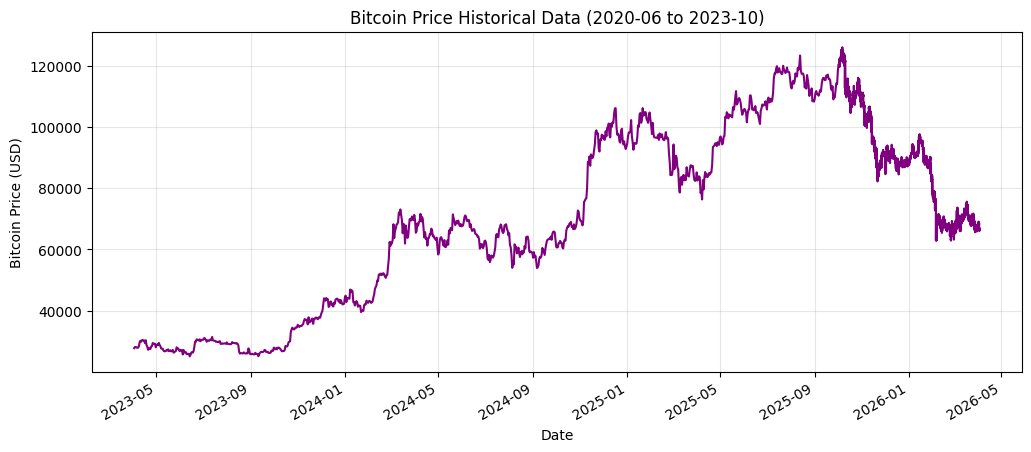

In [50]:
# Recipe 1-4C
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
btc_data['price'].plot(color='purple')

plt.ylabel('Bitcoin Price (USD)')
plt.title("Bitcoin Price Historical Data (2020-06 to 2023-10)")
plt.grid(alpha=0.3)
plt.show()



## Data Preparation: Resampling and Train/Val/Test Split (Hourly)

**Vấn đề:** Tập dữ liệu trộn lẫn giữa "Ngày" (3 năm) và "Giờ" (6 tháng) sẽ phá vỡ tính liên tục của cấu trúc chuỗi thời gian.
**Giải pháp mới (Theo Giờ):** Đồng nhất tất cả về dữ liệu Giờ (Hourly). Do 3 năm cũ chỉ có dữ liệu ngày (tức là 1 điểm mỗi 24 giờ), khi chuyển sang giờ sẽ bị thiếu (NaN) ở các giờ lẻ. Để giải quyết, ta sẽ dùng phương pháp **Nội suy tuyến tính (Linear Interpolation)** hoặc Điền giá trị trước đó (Forward Fill) để lấp đầy các khoảng trống. Sau đó chia Train/Val/Test (70-15-15).

Tổng số giờ liên tục (Hourly steps): 26297 tiếng
🔹 Tập Train: 18407 giờ (Từ 2023-04-03 00:00:00 đến 2025-05-08 22:00:00)
🔸 Tập Val  : 3944 giờ (Từ 2025-05-08 23:00:00 đến 2025-10-20 06:00:00)
🔺 Tập Test : 3946 giờ (Từ 2025-10-20 07:00:00 đến 2026-04-02 16:00:00)


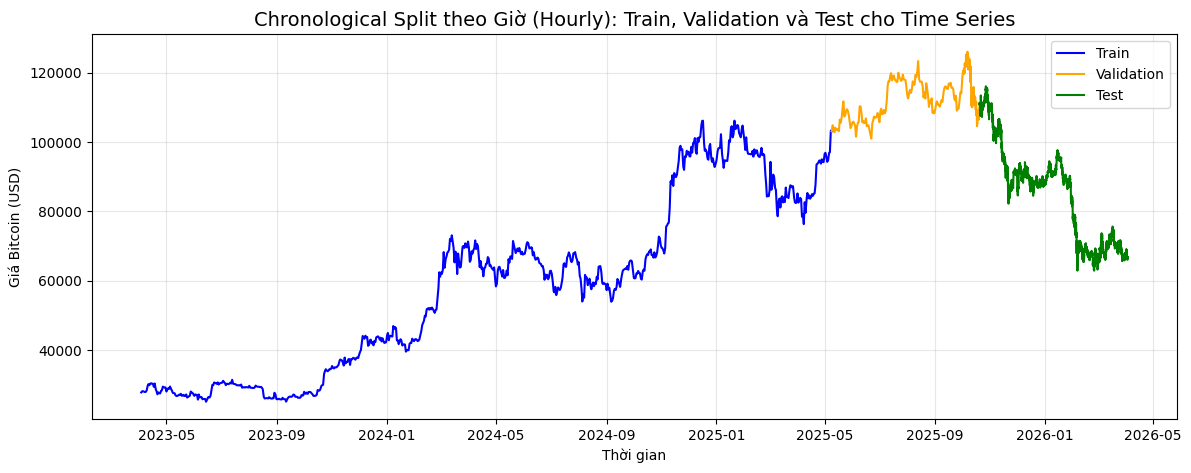

In [51]:
# 1. ĐỒNG NHẤT TẦN SUẤT VỀ GIỜ (HOURLY RESAMPLING & INTERPOLATION)
# Nhóm về tần suất giờ (H). Những khoảng trống do dữ liệu cũ chỉ ghi theo ngày sẽ sinh ra NaN.
# Phương pháp nội suy `interpolate()` sẽ tạo ra các điểm ảnh giả mạo mượt mà nối giữa 2 điểm ngày xa nhau.
df_hourly_unified = btc_data['price'].resample('h').mean().interpolate(method='linear')

# 2. CHIA TẬP TRAIN / VAL / TEST DỌC THEO THỜI GIAN (Chronological Split)
# Tỉ lệ chia cổ điển: 70% Train - 15% Validation - 15% Test
total_hours = len(df_hourly_unified)
train_size = int(total_hours * 0.70)
val_size = int(total_hours * 0.15)

train_data = df_hourly_unified.iloc[:train_size]
val_data = df_hourly_unified.iloc[train_size : train_size + val_size]
test_data = df_hourly_unified.iloc[train_size + val_size:]

print(f"Tổng số giờ liên tục (Hourly steps): {total_hours} tiếng")
print(f"🔹 Tập Train: {len(train_data)} giờ (Từ {train_data.index.min()} đến {train_data.index.max()})")
print(f"🔸 Tập Val  : {len(val_data)} giờ (Từ {val_data.index.min()} đến {val_data.index.max()})")
print(f"🔺 Tập Test : {len(test_data)} giờ (Từ {test_data.index.min()} đến {test_data.index.max()})")

# 3. VẼ BIỂU ĐỒ MINH HỌA VIỆC CHIA GIỜ TRÊN TỔNG THỂ
plt.figure(figsize=(14, 5))
plt.plot(train_data.index, train_data.values, color='blue', label='Train')
plt.plot(val_data.index, val_data.values, color='orange', label='Validation')
plt.plot(test_data.index, test_data.values, color='green', label='Test')

plt.title('Chronological Split theo Giờ (Hourly): Train, Validation và Test cho Time Series', fontsize=14)
plt.ylabel('Giá Bitcoin (USD)')
plt.xlabel('Thời gian')
plt.legend()
plt.grid(alpha=0.3)
plt.show()